In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math 

In [3]:
df = pd.read_csv("datasets/raw-data/nilai-gizi-fitur.csv", sep=";")
df.head()

,name,serving_size,energy_kcal,protein_g,carbohydrate_g,fat_g,sugar_g,sodium_mg,fiber_g
0,Ikan sunu,mentah,Tidak Diketahui,20.30 g,199.0,34.1,7.1,3.8,0.0
1,Soto pekalongan,Tidak Diketahui,1.30 g,94.0,3.0,5.1,6.8,0.0,0.0
2,Marie duo,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0
3,Kaparende,Tidak Diketahui,1.30 g,38.0,2.4,2.6,2.0,0.0,170.0
4,Kacang lebui / iris,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3


In [4]:
df.shape

(1649, 9)

In [5]:
df.dtypes

name               object
serving_size       object
energy_kcal        object
protein_g          object
carbohydrate_g     object
fat_g              object
sugar_g           float64
sodium_mg         float64
fiber_g           float64
dtype: object

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
#Data Cleaning dan Pre-processing EDA = utk mengetahui penyakit data
df.isnull().sum()

name              0
serving_size      0
energy_kcal       0
protein_g         0
carbohydrate_g    0
fat_g             0
sugar_g           0
sodium_mg         0
fiber_g           0
dtype: int64

In [8]:
df['name'] #data baru yg telah diproses

0                             Ikan sunu
1                       Soto pekalongan
2                             Marie duo
3                             Kaparende
4                   Kacang lebui / iris
                     ...               
1644     V-soy Soya bean Milk Low Sugar
1645                   Prenagen Esensis
1646                       Pisang ketip
1647                               Sapi
1648    Kacang tanah rebus dengan kulit
Name: name, Length: 1649, dtype: object

<Axes: >

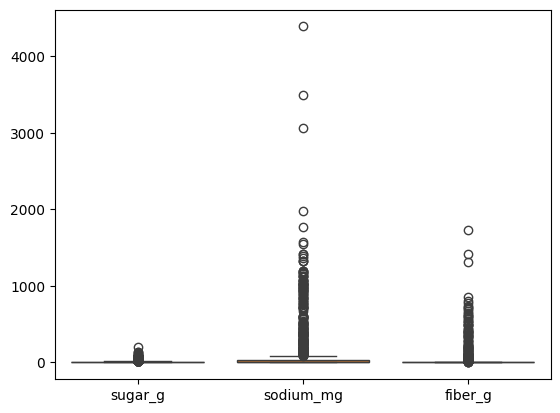

In [9]:
# deteksi outliers dgn seaborn
cols = ['energy_kcal', 'protein_g', 'carbohydrate_g', 'fat_g', 'sugar_g', 'sodium_mg', 'fiber_g']

sns.boxplot(data=df[cols])

In [10]:
print(df[cols].dtypes) # cek sebelumnya masih ada type object

energy_kcal        object
protein_g          object
carbohydrate_g     object
fat_g              object
sugar_g           float64
sodium_mg         float64
fiber_g           float64
dtype: object


In [11]:
cols_fix = ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrate_g']

for col in cols_fix:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace(' g', '', regex=False)
        .str.replace(' mg', '', regex=False)
        .replace(['Tidak Diketahui', 'tidak diketahui', 'TIDAK DIKETAHUI'], pd.NA)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [12]:
print(df[cols].dtypes) # cek tipe data

energy_kcal       float64
protein_g         float64
carbohydrate_g    float64
fat_g             float64
sugar_g           float64
sodium_mg         float64
fiber_g           float64
dtype: object


In [13]:
# hapus baris data yg ga lengkap
FEATURES = [
    'sugar_g',
    'sodium_mg',
    'fat_g',
    'energy_kcal',
    'protein_g',
    'fiber_g',
    'carbohydrate_g'
]

df = df.dropna(subset=FEATURES)

In [14]:
# hapus kadar nutrisi yang mustahil
df = df[
    (df['protein_g'] <= 90) &
    (df['fat_g'] <= 80) &
    (df['carbohydrate_g'] <= 400) &
    (df['sugar_g'] <= 50) &
    (df['fiber_g'] <= 40) &
    (df['energy_kcal'] <= 2700)
]

<Axes: >

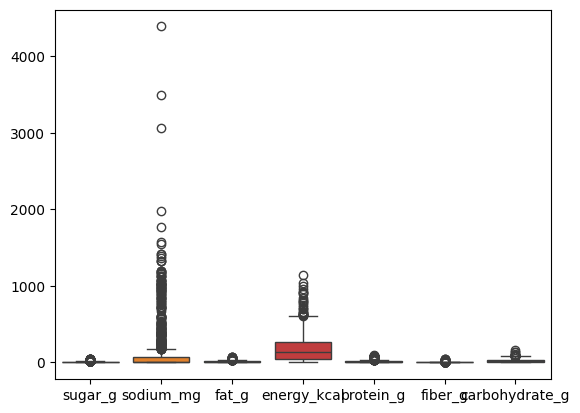

In [15]:
# simpan hasil logic threshold
df = df.copy()
sns.boxplot(data=df[FEATURES])

In [ ]:
df[FEATURES].describe(percentiles=[0.5, 0.60, 0.75, 0.9]) # ambil nilai yang 75%

,sugar_g,sodium_mg,fat_g,energy_kcal,protein_g,fiber_g,carbohydrate_g
count,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000,1303.000000
mean,3.854167,113.419647,8.101734,178.616669,11.330215,2.357882,24.875649
std,7.322069,309.469770,10.358369,173.119891,17.064194,5.114603,23.370174
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
45%,0.000000,0.000000,4.000000,110.000000,3.100000,0.000000,16.000000
50%,0.000000,0.000000,4.600000,130.000000,4.050000,0.200000,18.000000
60%,0.600000,8.000000,6.300000,160.000000,7.000000,1.000000,22.920000
75%,4.750000,68.500000,11.000000,271.500000,12.900000,2.200000,36.000000
90%,14.000000,346.000000,20.000000,416.000000,34.000000,6.000000,59.940000
max,50.000000,4393.000000,76.000000,1140.000000,90.000000,40.000000,165.000000


In [17]:
# FEATURE ENGINEERING: NUTRITION SCORE


limits = df[[
    'energy_kcal',
    'sugar_g',
    'fat_g',
    'sodium_mg',
    'carbohydrate_g'
]].quantile(0.60) # diturunin dari 0.75

bonus = df[[
    'protein_g',
    'fiber_g'
]].quantile(0.50)

def hitung_skor(row):
    skor = 0.0

    # poin negatif berbobot (SAMA PERSIS dengan klasifikasi_nutrisi)
    if row['sugar_g'] >= limits['sugar_g']:
        skor += 2.5
    if row['sodium_mg'] >= limits['sodium_mg']:
        skor += 2.5
    if row['fat_g'] >= limits['fat_g']:
        skor += 1.5
    if row['energy_kcal'] >= limits['energy_kcal']:
        skor += 1.0
    if row['carbohydrate_g'] >= limits['carbohydrate_g']:
        skor += 0.5

    # poin positif (maks 1)
    bonus_count = 0
    if row['protein_g'] >= bonus['protein_g']:
        bonus_count += 1
    if row['fiber_g'] >= bonus['fiber_g']:
        bonus_count += 1

    skor -= min(bonus_count, 1)

    return skor


# Tambahkan skor ke dataset
df['nutrition_score'] = df.apply(hitung_skor, axis=1)


In [18]:
# ambang batas
q45 = df['nutrition_score'].quantile(0.45)
q75 = df['nutrition_score'].quantile(0.75)

def klasifikasi_nutrisi(row):

    if row['nutrition_score'] <= q45:
        return 'Sehat'
    elif row['nutrition_score'] <= q75:
        return "Kurang Sehat"
    else:
        return 'Tidak Sehat'

In [19]:
df['label'] = df.apply(klasifikasi_nutrisi, axis=1) # simpan label dalam setiap baris dataset

# untuk sanity check
df[['nutrition_score', 'label']].head()

,nutrition_score,label
2,4.0,Kurang Sehat
4,3.0,Kurang Sehat
8,1.5,Sehat
9,1.5,Sehat
10,3.0,Kurang Sehat


In [20]:
# Cek banyak label
print(df['label'].value_counts())


label
Sehat           596
Kurang Sehat    425
Tidak Sehat     282
Name: count, dtype: int64


In [21]:
# cek sample label
df[['name', 'energy_kcal', 'sugar_g', 'fat_g', 'sodium_mg', 'protein_g', 'fiber_g', 'label']] \
    .sample(10)

,name,energy_kcal,sugar_g,fat_g,sodium_mg,protein_g,fiber_g,label
971,Geblek,195.0,0.0,1.7,353.0,0.4,3.6,Kurang Sehat
580,Mi basah,88.0,0.0,3.3,63.0,0.6,0.1,Kurang Sehat
1099,Buah negri,0.8,0.1,12.2,0.0,55.0,10.0,Sehat
265,Sonice Chicken nugget,250.0,0.0,14.0,0.0,16.0,0.0,Sehat
962,Yogurt frozen pinkberry (Medium),240.0,47.0,0.0,0.0,9.0,0.0,Kurang Sehat
445,King's Fisher sarden goreng balado,120.0,0.0,8.0,0.0,8.0,0.0,Sehat
1065,Pepea oncom ampas tahu,76.0,0.0,1.8,0.0,5.2,2.2,Sehat
806,Es krim Wall's oreo cookies cream,140.0,11.0,7.0,0.0,2.0,1.0,Kurang Sehat
1607,Petis ikan,165.0,0.0,0.2,0.0,20.0,0.0,Sehat
49,Nutrisari Yuzu Orange,45.0,9.0,0.0,20.0,0.0,0.0,Tidak Sehat


In [22]:
# simpan logic dan buat dataset bersih dalam bentuk .csv
df_final = df.copy()
df_final.to_csv("datasets/processed/nutrisi-cleaned.csv", index=False)

In [23]:
# Load dataset dan persiapan
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("datasets/processed/nutrisi-cleaned.csv") #load dataset yang udh diproses

# Nentuin Fitur(X) dan Target(Y)
fitur_gizi = [
    'sugar_g',
    'sodium_mg',
    'fat_g',
    'energy_kcal',
    'protein_g',
    'fiber_g',
    'carbohydrate_g'
]

X = df[fitur_gizi]
y = df['label'] 

# encoding label
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nMapping Label:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# train test split stratified

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Distribusi label:")
print(df['label'].value_counts(normalize=True)) # tadinya gada isi
print("\nMapping label:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nJumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))


Mapping Label:
{'Kurang Sehat': np.int64(0), 'Sehat': np.int64(1), 'Tidak Sehat': np.int64(2)}
Distribusi label:
label
Sehat           0.457406
Kurang Sehat    0.326170
Tidak Sehat     0.216424
Name: proportion, dtype: float64

Mapping label: {'Kurang Sehat': np.int64(0), 'Sehat': np.int64(1), 'Tidak Sehat': np.int64(2)}

Jumlah data train: 1042
Jumlah data test : 261


In [24]:
print("X_train shape:", X_train.shape)

X_train shape: (1042, 7)


In [25]:
# class imbalance handling (buat rf dan xgb)
from sklearn.utils.class_weight import compute_class_weight

# hitung bobot kelas
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes = classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {np.int64(0): np.float64(1.0215686274509803), np.int64(1): np.float64(0.7281621243885394), np.int64(2): np.float64(1.5437037037037038)}


In [26]:
# Scaling dan Cross-Validation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# scaling khusus untuk KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# pendefinisian model
models = [
    ('Random Forest', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'   
    )),
    ('XGBoost', XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    )),
    ('KNN', KNeighborsClassifier(n_neighbors=5))
]

# Stratifiend Cross-Val
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = 'f1_macro'

print("=== CROSS VALIDATION (F1 MACRO) ===")

for name, model in models:
    if name == 'KNN':
        scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring=scoring)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=skf, scoring=scoring)

    print(f"{name}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

=== CROSS VALIDATION (F1 MACRO) ===
Random Forest: Mean = 0.9547, Std = 0.0180
XGBoost: Mean = 0.9731, Std = 0.0084
KNN: Mean = 0.6754, Std = 0.0382


=== Evaluasi RF ===
              precision    recall  f1-score   support

Kurang Sehat       0.98      0.95      0.96        85
       Sehat       0.97      0.98      0.98       119
 Tidak Sehat       0.98      1.00      0.99        57

    accuracy                           0.98       261
   macro avg       0.98      0.98      0.98       261
weighted avg       0.98      0.98      0.98       261



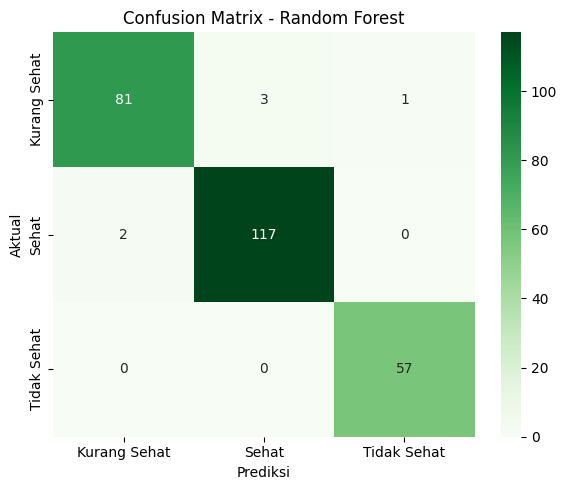

In [27]:
# Random Forest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

#definisi target name dari LabelEncoder
target_names = le.classes_

#training rf
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    # class_weight='balanced'
    class_weight=class_weight_dict
)

rf_model.fit(X_train, y_train)

#prediksi
y_pred_rf = rf_model.predict(X_test)

#evaluasi
print("=== Evaluasi RF ===")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=target_names
))

# confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

=== EVALUASI XGBOOST ===
              precision    recall  f1-score   support

       Sehat       0.99      0.98      0.98        85
Kurang Sehat       0.99      0.99      0.99       119
 Tidak Sehat       0.98      1.00      0.99        57

    accuracy                           0.99       261
   macro avg       0.99      0.99      0.99       261
weighted avg       0.99      0.99      0.99       261



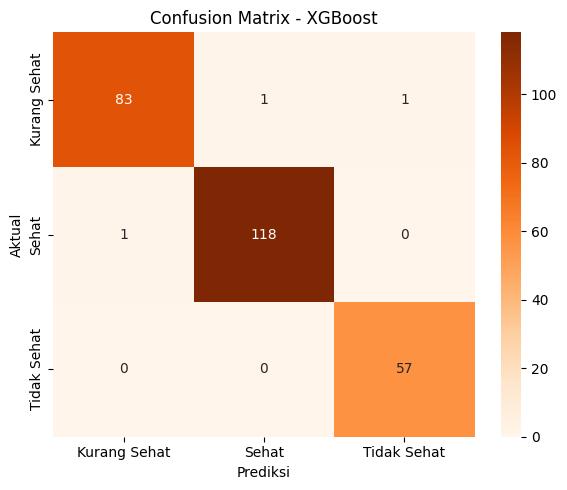

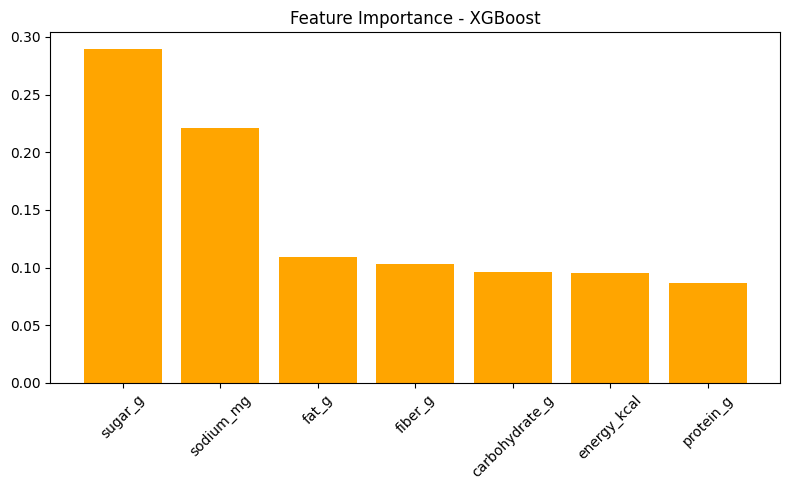

In [28]:
#XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    
    max_depth=4, # perubahan
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test)

#evaluasi
print("=== EVALUASI XGBOOST ===")
print(classification_report(
    y_test,
    y_pred_xgb,
    # target_names=target_names
    target_names=['Sehat', 'Kurang Sehat', 'Tidak Sehat']
))

# confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices], color='orange')
plt.xticks(range(len(importances)), np.array(X.columns)[indices], rotation=45)
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

=== EVALUASI KNN ===
              precision    recall  f1-score   support

Kurang Sehat       0.62      0.65      0.64        85
       Sehat       0.77      0.80      0.78       119
 Tidak Sehat       0.80      0.68      0.74        57

    accuracy                           0.72       261
   macro avg       0.73      0.71      0.72       261
weighted avg       0.73      0.72      0.72       261



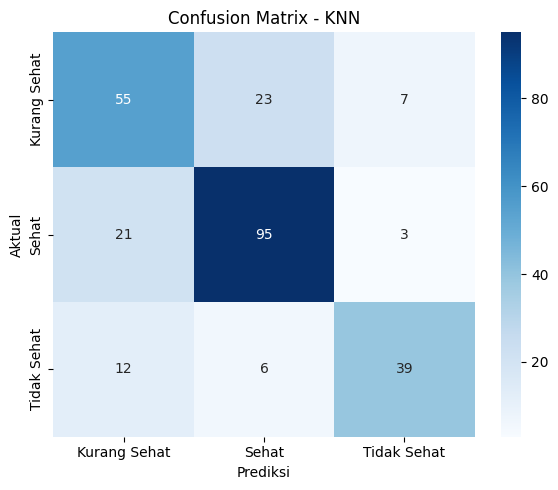

In [29]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# scaling data test (WAJIB)
X_test_scaled = scaler.transform(X_test)

# training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# prediksi
y_pred_knn = knn_model.predict(X_test_scaled)

# evaluasi
print("=== EVALUASI KNN ===")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=target_names
))

# confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

In [30]:
import joblib

paket_model = {
    'model': xgb_model,          # ← XGBOOST
    'scaler': scaler,            # scaler yang sama dari training
    'label_encoder': le,         # encoder label
    'features': fitur_gizi       # urutan fitur FINAL
}

joblib.dump(paket_model, "model/model-train.pkl")
print("✅ Model FINAL (XGBoost) berhasil disimpan")

✅ Model FINAL (XGBoost) berhasil disimpan


In [31]:
paket = joblib.load("model/model-train.pkl")

model = paket['model']
scaler = paket['scaler']
le = paket['label_encoder']
features = paket['features']

In [32]:
# test data baru masuk buat prediksi

# sehat
# data_baru = [[
#     5,     # sugar_g
#     300,   # sodium_mg
#     6,     # fat_g
#     180,   # energy_kcal
#     8,     # protein_g
#     3,     # fiber_g
#     30     # carbohydrate_g
# ]]

# kurang sehat
# data_baru = [[
#     36,
#     1000,
#     18,
#     420,  
#     1,
#     0,
#     54
# ]]

#tidak sehat
data_baru = [[
    50,    # sugar_g
    3000,  # sodium_mg
    100,    # fat_g
    2300,   # energy_kcal
    0,     # protein_g
    0,     # fiber_g
    1000     # carbohydrate_g
]]

df_baru = pd.DataFrame(data_baru, columns=fitur_gizi)

In [33]:
data_scaled = scaler.transform(df_baru) #scaling 

In [34]:
# hasil prediksi data baru
pred_angka = model.predict(data_scaled)[0]
pred_label = le.inverse_transform([pred_angka])[0]

print("Hasil klasifikasi:", pred_label)

Hasil klasifikasi: Tidak Sehat


In [35]:
# probabilitas label
proba = model.predict_proba(data_scaled)[0]

for lbl, p in zip(le.classes_, proba):
    print(f"{lbl}: {p:.2%}")

Kurang Sehat: 15.46%
Sehat: 0.01%
Tidak Sehat: 84.54%
